# Projeto: Segmentação de Clientes de Cartão de Crédito

### **Objetivo do Projeto**
O principal objetivo deste projeto é desenvolver um modelo de agrupamento (**Clustering**) para segmentar a base de clientes de uma operadora de cartões de crédito. Através da análise de comportamentos de uso, padrões de gastos e hábitos de pagamento, buscamos identificar perfis distintos (Personas) que permitam:

1.  **Entender o Perfil de Consumo:** Diferenciar clientes que usam o cartão para compras diárias daqueles que o utilizam como linha de crédito emergencial (saques).
2.  **Gestão de Risco:** Identificar grupos com alta utilização de limite e baixas taxas de pagamento para mitigar inadimplência.
3.  **Estratégias de Marketing:** Personalizar ofertas e limites de acordo com a necessidade de cada segmento.
4.  **Aumento de Engajamento:** Criar ações para reativar clientes inativos ou incentivar o uso de transações à vista/parceladas conforme o perfil identificado.

Este notebook percorre desde a análise exploratória e tratamento de dados até a validação dos clusters usando técnicas de **Explainable AI (SHAP)**.

##Dataset utilizado

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

##Bibliotecas instaladas

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.1 MB/s eta 0:00:00


In [ ]:
!pip install shap

##Bibliotecas utilizadas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, classification_report, ConfusionMatrixDisplay
import optuna
import optuna.visualization.matplotlib as optuna_vis_mpl
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import shap
import joblib

##Carregando e limpando Dataset

In [ ]:
df = pd.read_csv('credit.csv')

# verificando colunas existentes
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [ ]:
# verificando linhas e colunas
print(f"Dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

Dataset possui 8950 linhas e 18 colunas.


In [ ]:
# verificando as 5 primeiras linhas
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
# verificando os dados nulos
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
# removendo o identificador do cliente
df = df.drop(columns=['CUST_ID'])

In [ ]:
# preenchendo dados nulos com a mediana para não descartar 313 linhas e não ser afetado por outliers
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

In [ ]:
# verificando dataset sem nulos
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


##Testes de hipóteses para verificar diferenças entre grupos

Hipótese 1: Pagamento Integral vs. Limite de Crédito

* $H_0$ (Nula): A média do limite de crédito dos clientes que pagam a maior parte da fatura é igual à dos que pagam o mínimo.

* $H_1$ (Alternativa): Existe uma diferença significativa na média do limite de crédito entre esses dois grupos.

In [ ]:
# separando grupos
h1_paga_pouco = df[df['PRC_FULL_PAYMENT'] < 0.5]['CREDIT_LIMIT']
h1_paga_muito = df[df['PRC_FULL_PAYMENT'] >= 0.5]['CREDIT_LIMIT']

In [ ]:
# teste estatístico
t_stat1, p_value1 = stats.ttest_ind(h1_paga_pouco, h1_paga_muito, equal_var=False)

print(f"Estatística t: {t_stat1}")
print(f"Valor-p: {p_value1}")

if p_value1 < 0.05:
    print("Conclusão: Rejeitamos H0. Há diferença significativa no limite de crédito.")
else:
    print("Conclusão: Falhamos em rejeitar H0.")

Estatística t: -4.153188844705884
Valor-p: 3.450035016045132e-05
Conclusão: Rejeitamos H0. Há diferença significativa no limite de crédito.


/tmp/ipykernel_1021/2947247847.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([h1_paga_pouco, h1_paga_muito], labels=['Paga < 50%', 'Paga >= 50%'])


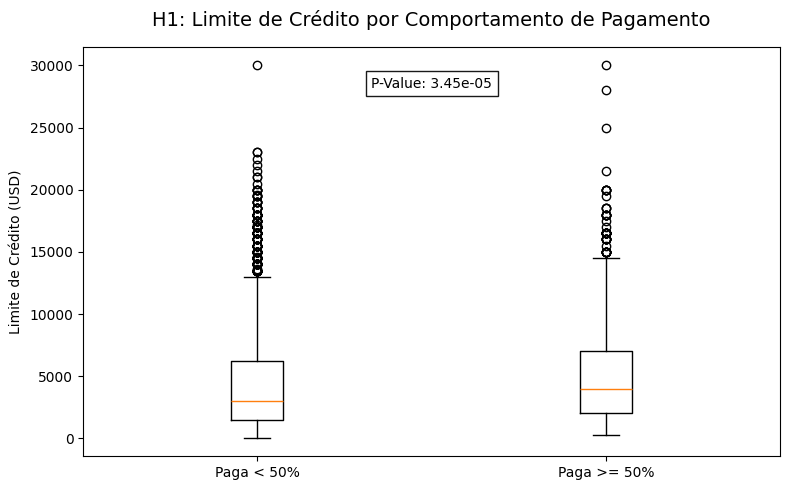

In [ ]:
# visualizando
plt.figure(figsize=(8, 5))
plt.boxplot([h1_paga_pouco, h1_paga_muito], labels=['Paga < 50%', 'Paga >= 50%'])

plt.title('H1: Limite de Crédito por Comportamento de Pagamento', fontsize=14, pad=15)
plt.ylabel('Limite de Crédito (USD)')
plt.text(0.5, 0.90, f'P-Value: {p_value1:.2e}', transform=plt.gca().transAxes, ha='center', bbox=dict(facecolor='white', alpha=0.9))
plt.tight_layout()
plt.show()

Hipótese 2: Saque Emergencial vs. Volume de Compras

* $H_0$ (Nula): Clientes que fazem saque em dinheiro gastam em compras no cartão a mesma quantia média que os clientes que não fazem saque.

* $H_1$ (Alternativa): Existe uma diferença significativa no volume médio de compras entre quem faz e quem não faz saque.

In [ ]:
# separando grupos
h2_sem_saque = df[df['CASH_ADVANCE'] == 0]['PURCHASES']
h2_com_saque = df[df['CASH_ADVANCE'] > 0]['PURCHASES']

In [ ]:
# teste estatístico
t_stat2, p_value2 = stats.ttest_ind(h2_sem_saque, h2_com_saque, equal_var=False)

print(f"Estatística t: {t_stat2}")
print(f"Valor-p: {p_value2}")

if p_value2 < 0.05:
    print("Conclusão: Rejeitamos H0. Há diferença significativa no volume de compras.")
else:
    print("Conclusão: Falhamos em rejeitar H0.")

Estatística t: 16.255630892274098
Valor-p: 1.7556828361737876e-58
Conclusão: Rejeitamos H0. Há diferença significativa no volume de compras.


/tmp/ipykernel_1021/390170964.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([h2_sem_saque, h2_com_saque], labels=['Sem Saque', 'Fez Saque'])


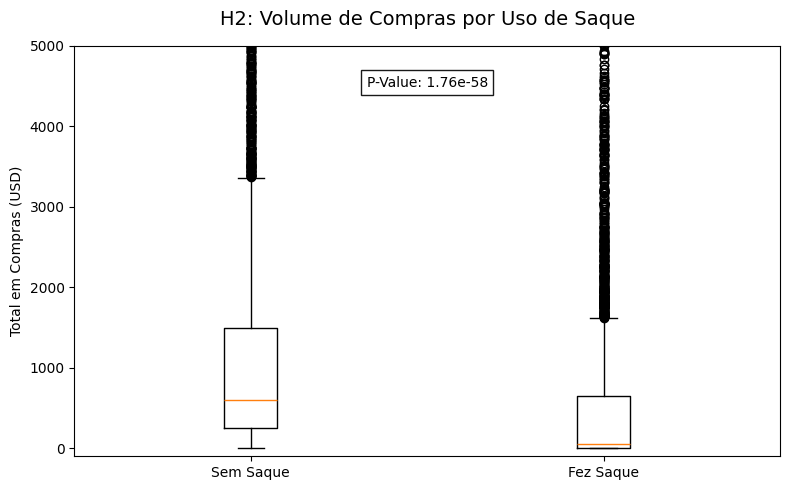

In [ ]:
# visualizando
plt.figure(figsize=(8, 5))
plt.boxplot([h2_sem_saque, h2_com_saque], labels=['Sem Saque', 'Fez Saque'])

plt.title('H2: Volume de Compras por Uso de Saque', fontsize=14, pad=15)
plt.ylabel('Total em Compras (USD)')
plt.ylim(-100, 5000)
plt.text(0.5, 0.90, f'P-Value: {p_value2:.2e}', transform=plt.gca().transAxes, ha='center', bbox=dict(facecolor='white', alpha=0.9))
plt.tight_layout()
plt.show()

Hipótese 3: Tempo de Conta (Fidelidade) vs. Saldo Devedor

* $H_0$ (Nula): O saldo devedor médio dos clientes mais antigos (12 meses) é igual ao dos clientes mais recentes (< 12 meses).

* $H_1$ (Alternativa): Existe uma diferença significativa no saldo devedor médio com base na fidelidade do cliente.

In [ ]:
# separando grupos
h3_recentes = df[df['TENURE'] < 12]['BALANCE']
h3_antigos = df[df['TENURE'] == 12]['BALANCE']

In [ ]:
# teste estatístico
t_stat3, p_value3 = stats.ttest_ind(h3_recentes, h3_antigos, equal_var=False)

print(f"Estatística t: {t_stat3}")
print(f"Valor-p: {p_value3}")

if p_value3 < 0.05:
    print("Conclusão: Rejeitamos H0. Há diferença significativa no saldo devedor.")
else:
    print("Conclusão: Falhamos em rejeitar H0.")

Estatística t: -6.813715326352322
Valor-p: 1.2236927622392865e-11
Conclusão: Rejeitamos H0. Há diferença significativa no saldo devedor.


/tmp/ipykernel_1021/3464563958.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([h3_recentes, h3_antigos], labels=['< 12 Meses', '12 Meses (Fiéis)'])


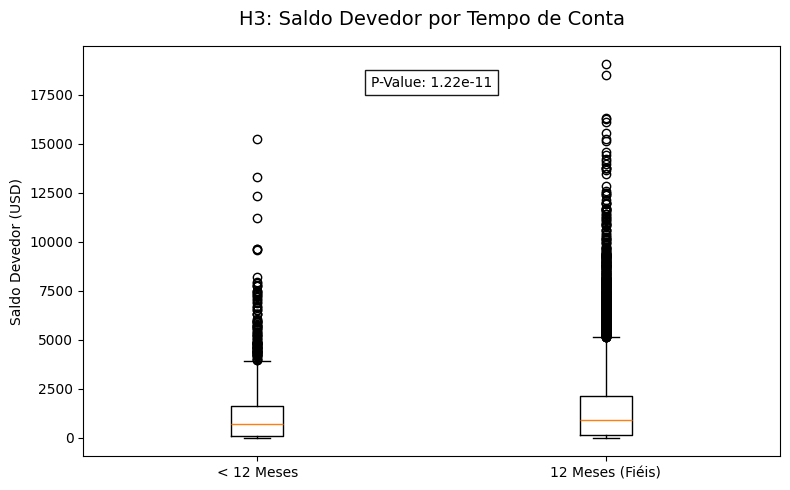

In [ ]:
# visualizando
plt.figure(figsize=(8, 5))
plt.boxplot([h3_recentes, h3_antigos], labels=['< 12 Meses', '12 Meses (Fiéis)'])

plt.title('H3: Saldo Devedor por Tempo de Conta', fontsize=14, pad=15)
plt.ylabel('Saldo Devedor (USD)')
plt.text(0.5, 0.90, f'P-Value: {p_value3:.2e}', transform=plt.gca().transAxes, ha='center', bbox=dict(facecolor='white', alpha=0.9))
plt.tight_layout()
plt.show()

## Matriz de correlação para verificar correlação entre as variáveis

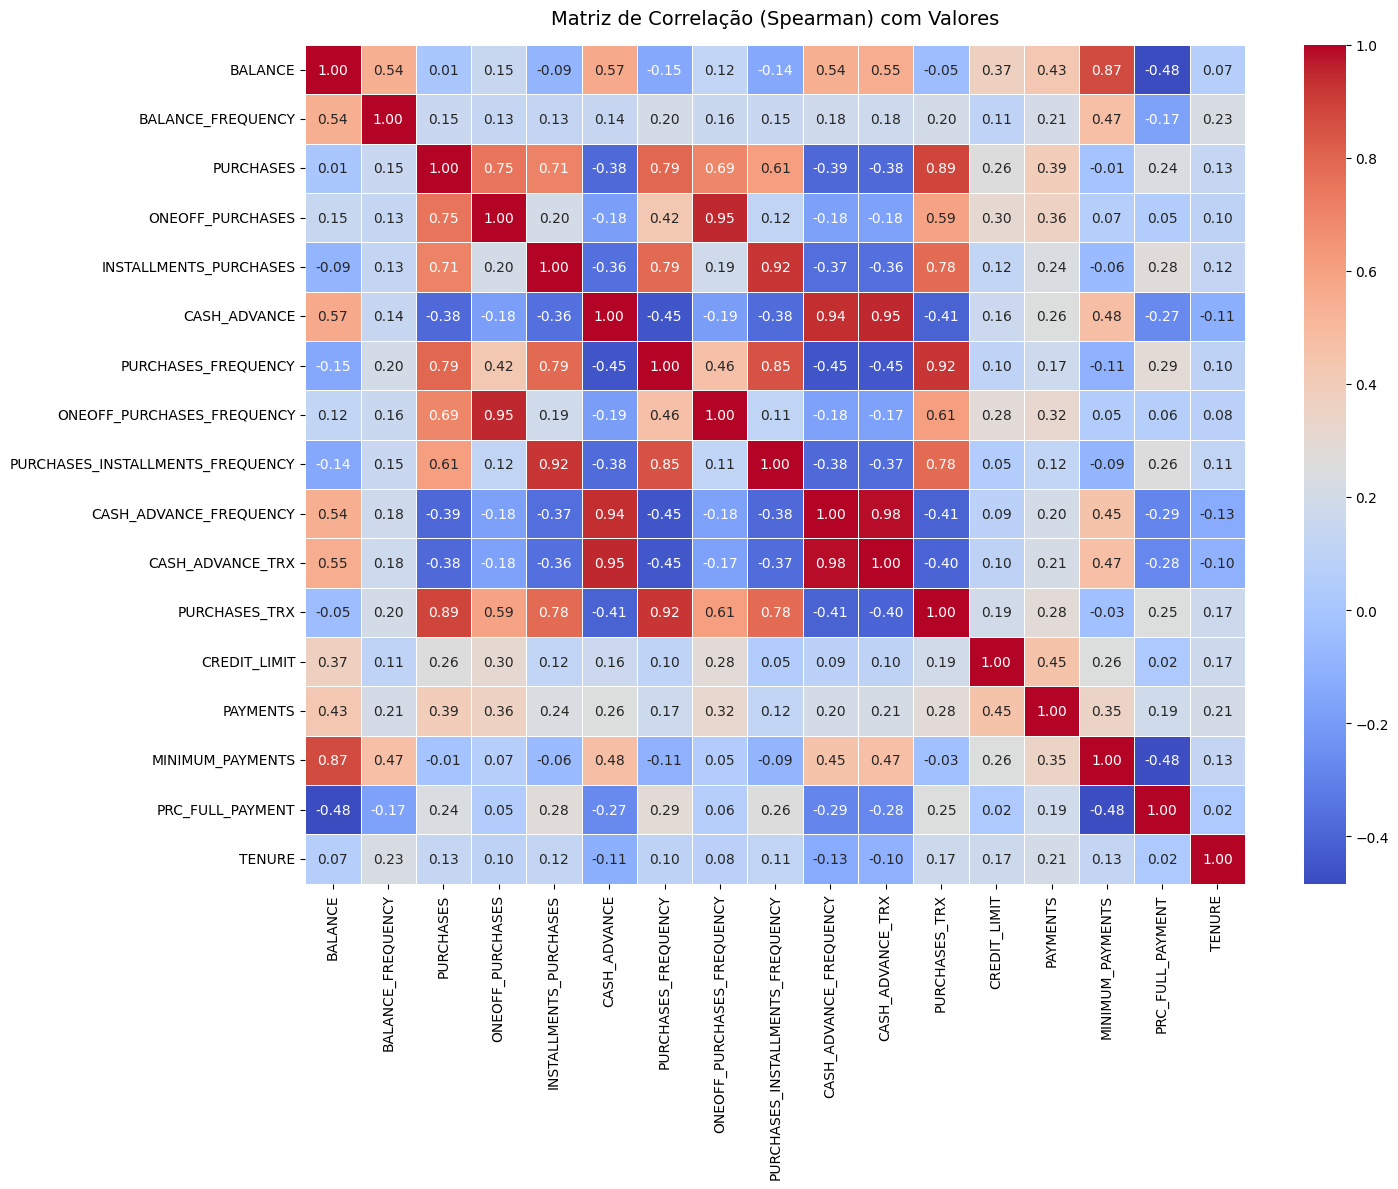

In [ ]:
corr_matrix = df.corr(method='spearman')

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Matriz de Correlação (Spearman) com Valores', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Remoção de Colunas Colineares
Com base na análise da matriz de correlação, vamos remover colunas que representam informações redundantes para evitar viés no algoritmo de clustering.

In [ ]:
# colunas que são redundantes ou altamente correlacionadas (>0.80)
colunas_para_remover = [
    'ONEOFF_PURCHASES', # já capturado por PURCHASES
    'INSTALLMENTS_PURCHASES', # já capturado por PURCHASES
    'PURCHASES_INSTALLMENTS_FREQUENCY', # altamente correlacionado com PURCHASES_FREQUENCY
    'CASH_ADVANCE_TRX', # altamente correlacionado com CASH_ADVANCE_FREQUENCY
    'PURCHASES_TRX', # altamente correlacionado com PURCHASES
    'PURCHASES_FREQUENCY', # altamente correlacionado com PURCHASES e PURCHASES_TRX
    'CASH_ADVANCE_FREQUENCY', # altamente correlacionado com CASH ADVANCE
]

df_reduzido = df.drop(columns=colunas_para_remover)

print(f"Colunas restantes: {df_reduzido.shape[1]}")
display(df_reduzido.head())

Colunas restantes: 10


,BALANCE,BALANCE_FREQUENCY,PURCHASES,CASH_ADVANCE,ONEOFF_PURCHASES_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.000000,0.000000,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,6442.945483,0.000000,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,0.000000,1.000000,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,205.788017,0.083333,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,0.000000,0.083333,1200.0,678.334763,244.791237,0.000000,12


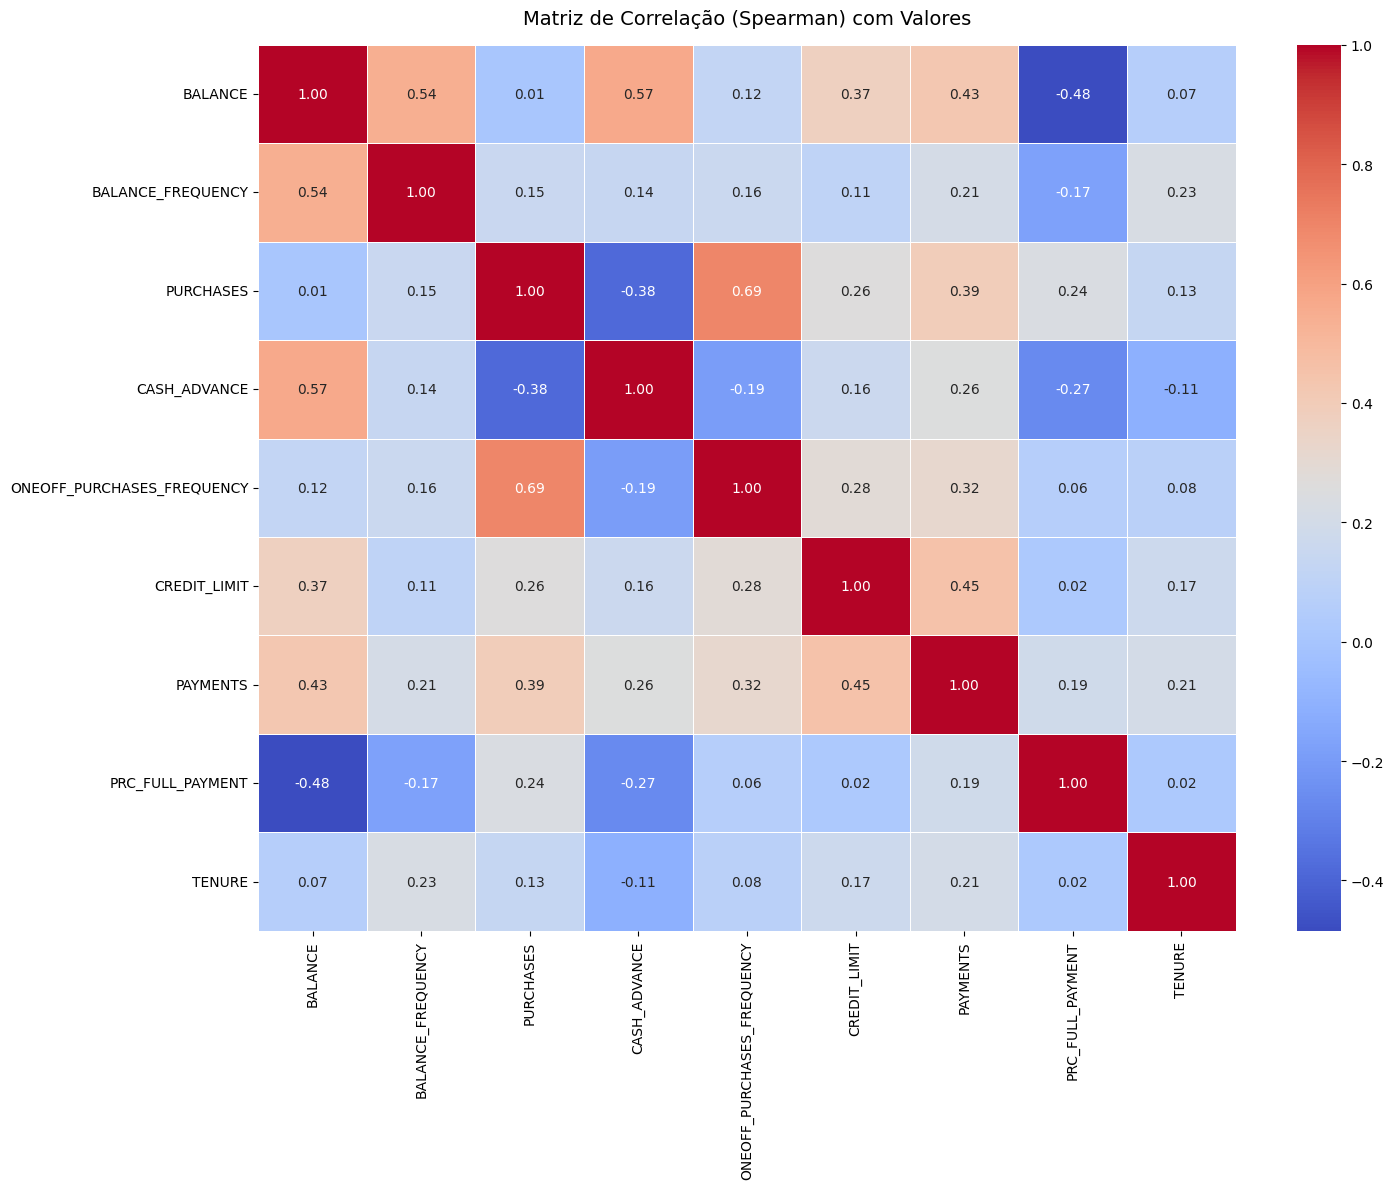

In [ ]:
# visualizando matriz após remoção inicial
corr_matrix2 = df_reduzido.corr(method='spearman')

plt.figure(figsize=(15, 12))
# annot=True exibe os valores, fmt='.2f' limita as casas decimais e cmap define as cores
sns.heatmap(corr_matrix2, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Matriz de Correlação (Spearman) com Valores', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Feature engineering

In [ ]:
# criando cópia do dataset
df_eng = df_reduzido.copy()

# criando novas colunas
# taxa de utilização de crédito (O quão perto do limite o cliente está?)
df_eng['CREDIT_UTILIZATION'] = df_eng['BALANCE'] / df_eng['CREDIT_LIMIT']

# taxa de pagamento (Qual a proporção do pagamento feito em relação ao mínimo exigido?)
# somamos 1e-6 para evitar erro matemático de divisão por zero
df_eng['PAYMENT_RATIO'] = df_eng['PAYMENTS'] / (df_eng['MINIMUM_PAYMENTS'] + 1e-6)

# remover as colunas absolutas que deram origem às taxas para evitar redundância
colunas_base = ['BALANCE', 'PAYMENTS', 'MINIMUM_PAYMENTS']
df_eng = df_eng.drop(columns=colunas_base)

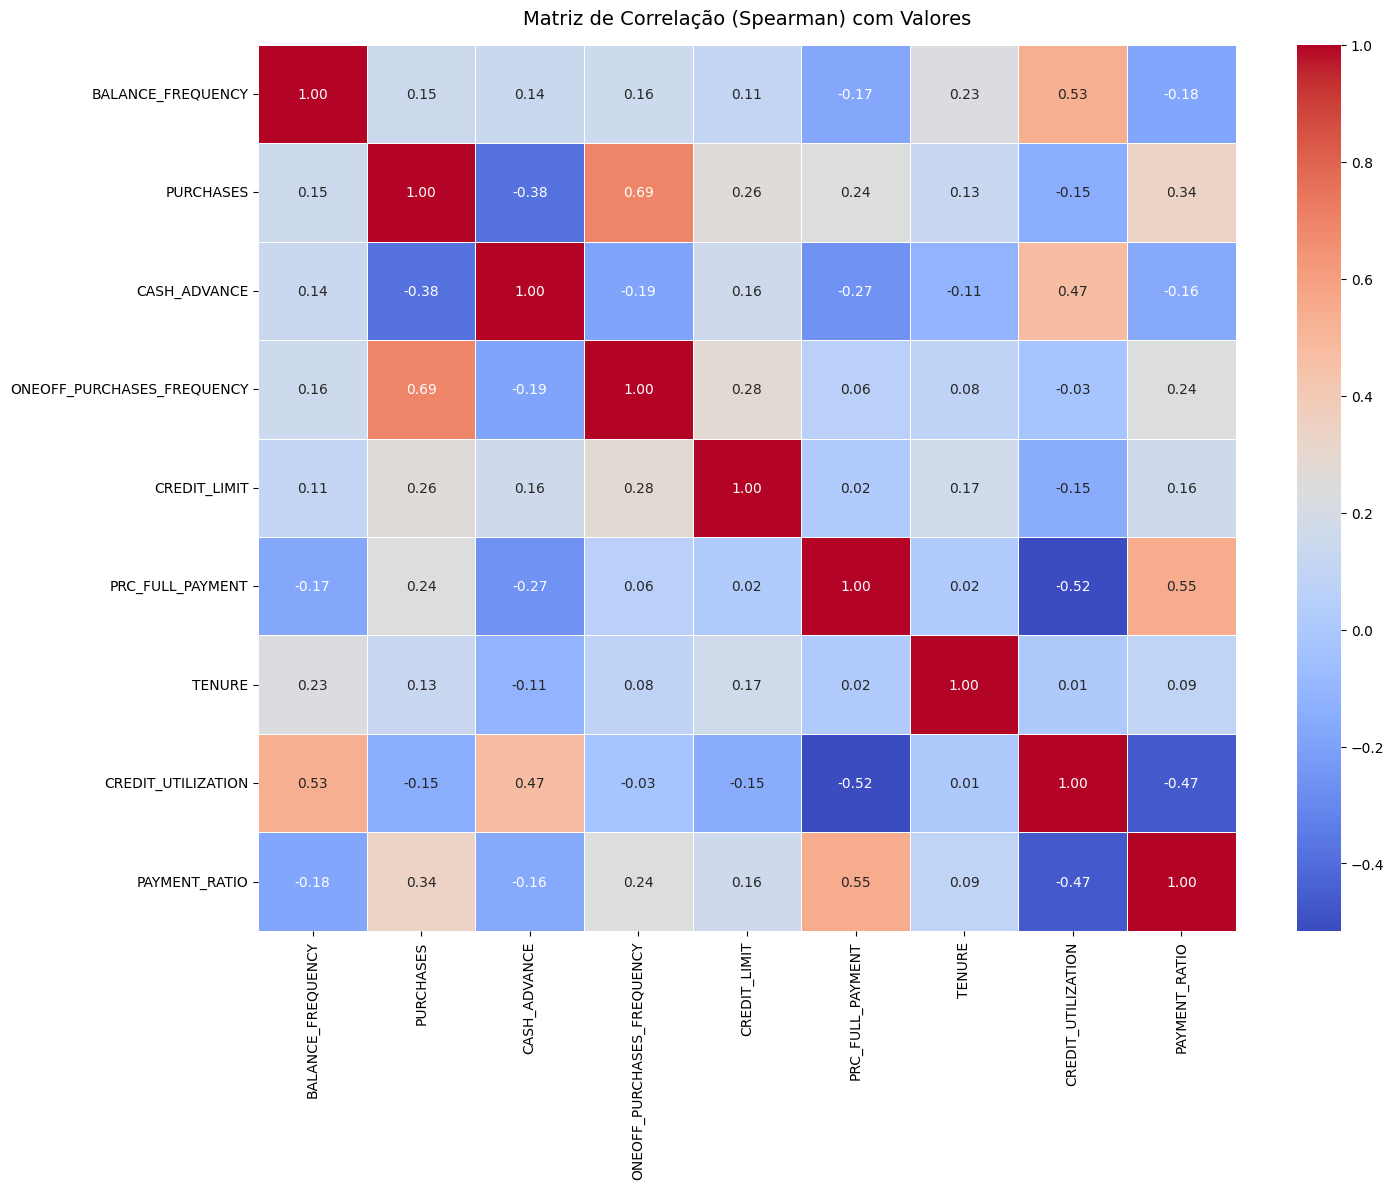

In [ ]:
# matriz de correlação final
corr_matrix_final = df_eng.corr(method='spearman')

plt.figure(figsize=(15, 12))
# annot=True exibe os valores, fmt='.2f' limita as casas decimais e cmap define as cores
sns.heatmap(corr_matrix_final, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Matriz de Correlação (Spearman) com Valores', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Divisão dos Dados (Train, Val, Test) e Escalonamento

In [ ]:
# features
X = df_eng.copy()

# divisão inicial dos dados: 70% Treino e 30% restante (que será dividido em Validação e Teste)
X_train, X_temp = train_test_split(X, test_size=0.30, random_state=42)

# divisão final: 15% Validação e 15% Teste
X_val, X_test = train_test_split(X_temp, test_size=0.50, random_state=42)

In [ ]:
# escalonamento (Evitando Data Leakage)
scaler = StandardScaler()

# aprende e transforma usando somente dados de Treino
X_train_scaled = scaler.fit_transform(X_train)

# transformando dados de Validação e Teste
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# convertendo de volta para DataFrame para preservar os nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Treino: {X_train_scaled.shape[0]} clientes")
print(f"Validação: {X_val_scaled.shape[0]} clientes")
print(f"Teste: {X_test_scaled.shape[0]} clientes")

Treino: 6265 clientes
Validação: 1342 clientes
Teste: 1343 clientes


## Método do Cotovelo (Elbow Method) e Silhouette Score para definir o número de clusters

In [ ]:
inercia = []
silhouette_scores = []
K_range = range(2, 11)

# rodando o KMeans para K de 2 até 10 usando dados de Treino
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)

    inercia.append(kmeans.inertia_)

    # usando Silhouette Score para avaliar avalia se os clusters estão bem separados
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_scores.append(score)

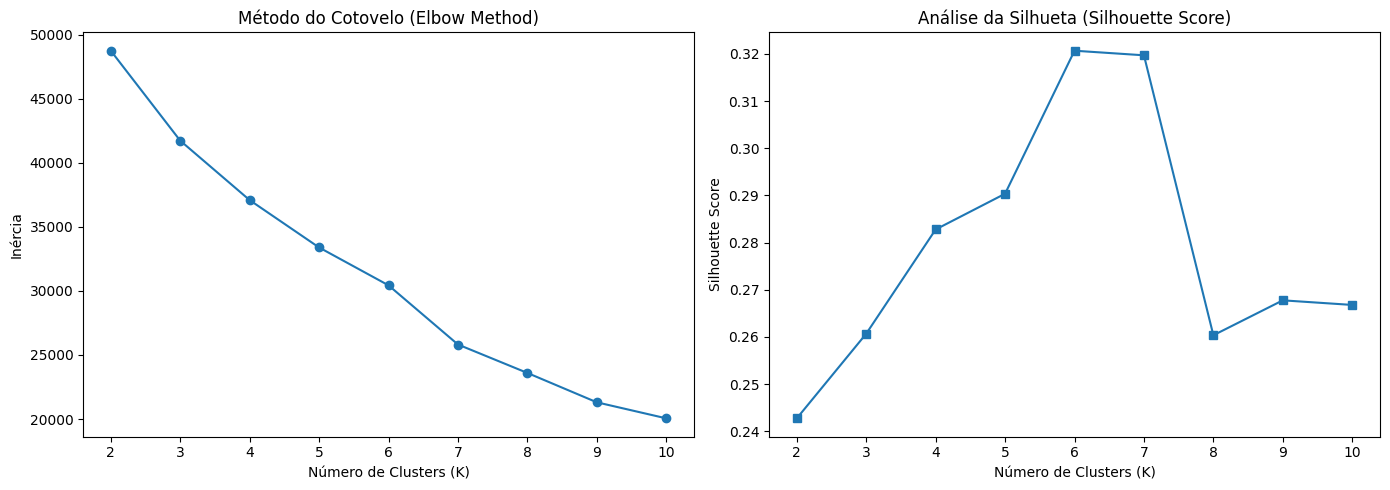

In [ ]:
# visualizando resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# gráfico 1: Elbow Method
ax1.plot(K_range, inercia, marker='o')
ax1.set_title('Método do Cotovelo (Elbow Method)')
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inércia')

# gráfico 2: Silhouette Score
ax2.plot(K_range, silhouette_scores, marker='s')
ax2.set_title('Análise da Silhueta (Silhouette Score)')
ax2.set_xlabel('Número de Clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

Há uma queda em K=6 no método do cotovelo e o Silhouette Score tem seu pico em K=6, isso sugere que a quantidade de grupos ideais são 6

##Comparação de Algoritmos com valores padrão (K-Means vs. Hierárquico vs. DBSCAN)

In [ ]:
# K-Means
# Usamos k=6 conforme definido pelo Silhouette Score e Elbow Method da etapa anterior
kmeans_model = KMeans(n_clusters=6, random_state=42, n_init='auto')
kmeans_labels = kmeans_model.fit_predict(X_train_scaled)
score_kmeans = silhouette_score(X_train_scaled, kmeans_labels)

In [ ]:
# Agglomerative Clustering (Hierárquico)
hierarchical_model = AgglomerativeClustering(n_clusters=6)
hierarchical_labels = hierarchical_model.fit_predict(X_train_scaled)
score_hierarchical = silhouette_score(X_train_scaled, hierarchical_labels)

In [ ]:
# DBSCAN (Baseado em Densidade)
dbscan_model = DBSCAN(eps=2.0, min_samples=10)
dbscan_labels = dbscan_model.fit_predict(X_train_scaled)
if len(set(dbscan_labels)) > 1:
    # removemos o ruído (-1) do cálculo de avaliação para não penalizar injustamente o algoritmo
    mask_no_noise = dbscan_labels != -1
    if len(set(dbscan_labels[mask_no_noise])) > 1:
        score_dbscan = silhouette_score(X_train_scaled[mask_no_noise], dbscan_labels[mask_no_noise])
    else:
        score_dbscan = "Apenas 1 cluster não-ruído"
else:
    score_dbscan = "Apenas ruído encontrado"

In [ ]:
print("Performance dos modelos base (K=6)")
print(f"1. K-Means Silhouette Score:         {score_kmeans:.4f}")
print(f"2. Hierarchical Silhouette Score:    {score_hierarchical:.4f}")

if isinstance(score_dbscan, str):
    print(f"3. DBSCAN Silhouette Score:          {score_dbscan} (Parâmetros ruins)")
else:
    print(f"3. DBSCAN Silhouette Score:          {score_dbscan:.4f} (Excluindo ruído)")

Performance dos modelos base (K=6)
1. K-Means Silhouette Score:         0.3207
2. Hierarchical Silhouette Score:    0.2636
3. DBSCAN Silhouette Score:          Apenas 1 cluster não-ruído (Parâmetros ruins)


In [ ]:
scores = {'K-Means': score_kmeans, 'Hierarchical': score_hierarchical}
vencedor = max(scores, key=scores.get)

print(f"Modelo Vencedor para os dados atuais: {vencedor} com Silhouette de {scores[vencedor]:.4f}")

Modelo Vencedor para os dados atuais: K-Means com Silhouette de 0.3207


## Otimizando KMeans com Optuna

In [ ]:
# desativando os logs verbosos do Optuna para manter o painel limpo
optuna.logging.set_verbosity(optuna.logging.WARNING)

# definindo a Função Objetivo para o Optuna
def objective(trial):
    # intervalos de valores definidos
    n_clusters = trial.suggest_int('n_clusters', 3, 7)
    init_method = trial.suggest_categorical('init', ['k-means++', 'random'])
    n_init = trial.suggest_int('n_init', 10, 30)
    max_iter = trial.suggest_int('max_iter', 300, 800)

    # instanciando o modelo
    kmeans_opt = KMeans(
        n_clusters=n_clusters,
        init=init_method,
        n_init=n_init,
        max_iter=max_iter,
        random_state=42
    )

    # Treinando no conjunto de Treino
    kmeans_opt.fit(X_train_scaled)

    # Avaliando no conjunto de Validação
    val_labels = kmeans_opt.predict(X_val_scaled)

    # calculando a pontuação na Validação
    score = silhouette_score(X_val_scaled, val_labels)

    return score

# criando o Estudo para maximizar o Silhouette Score)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

In [ ]:
print("Resultados:")
print(f"Melhor Silhouette Score na Validação: {study.best_value:.4f}")
print("Melhores Hiperparâmetros Encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

Resultados:
Melhor Silhouette Score na Validação: 0.3242
Melhores Hiperparâmetros Encontrados:
  - n_clusters: 6
  - init: random
  - n_init: 25
  - max_iter: 473


Melhor resultado:

Silhouette Score na Validação: 0.3242

Hiperparâmetros Encontrados:
  - n_clusters: 6
  - init: random
  - n_init: 25
  - max_iter: 473

## Visualizando os resultados

/tmp/ipykernel_1021/1345953555.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna_vis_mpl.plot_optimization_history(study)


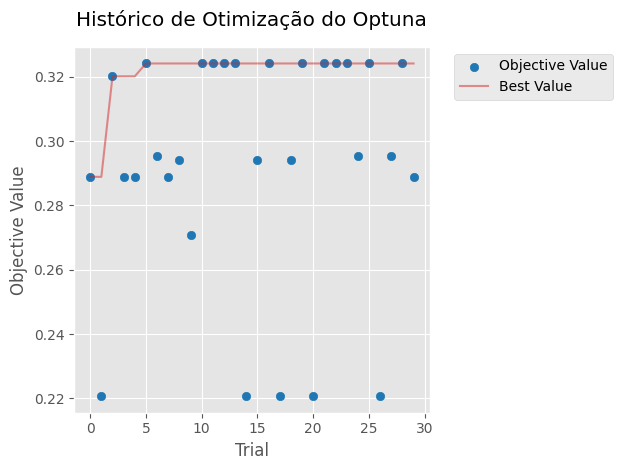

In [ ]:
# visualizando resultdos
fig = optuna_vis_mpl.plot_optimization_history(study)
plt.title('Histórico de Otimização do Optuna', pad=15)
plt.tight_layout()
plt.show()

Após 6 grupos (0 até 5) ele para de criar novos grupos se tornando linear

##Visualizando os 6 grupos

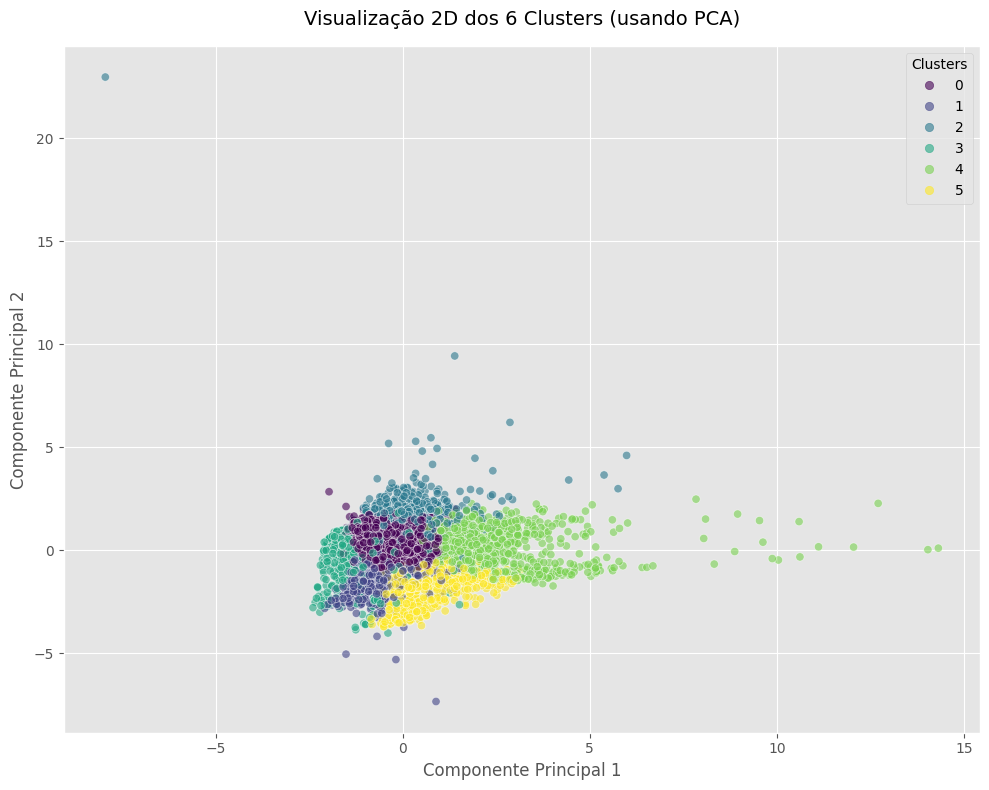

0    2961
1     774
2     511
3     463
4     873
5     683
Name: count, dtype: int64


In [ ]:
# instanciando o modelo com os melhores parâmetros encontrados pelo Optuna
melhor_k = 6
kmeans_otimizado = KMeans(
    n_clusters=melhor_k,
    init='random',
    n_init=25,
    max_iter=473,
    random_state=42
)

# treinando e obtendo os rótulos (labels) definitivos para os dados de Treino
labels_treino = kmeans_otimizado.fit_predict(X_train_scaled)

# redução de Dimensionalidade (PCA) para visualização em 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# visualizando usando gráfico de Dispersão (Scatterplot)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=labels_treino, cmap='viridis', alpha=0.6, edgecolors='w', linewidth=0.5)
plt.title(f'Visualização 2D dos {melhor_k} Clusters (usando PCA)', fontsize=14, pad=15)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# legenda baseada nos clusters (C0 até C5)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")

plt.tight_layout()
plt.show()

print(pd.Series(labels_treino).value_counts().sort_index())

Vemos que os grupos apesar de estarem bem próximos estão bem definidos, com o grupo 0 tendo a maior quantidade de consumidores, sendo provavelmente o grupo padrão

##Matriz de Confusão com dados de Teste

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       654
           1       0.96      0.99      0.98       173
           2       0.93      0.97      0.95        99
           3       0.95      0.99      0.97        99
           4       0.95      0.93      0.94       172
           5       0.99      0.91      0.95       146

    accuracy                           0.97      1343
   macro avg       0.96      0.96      0.96      1343
weighted avg       0.97      0.97      0.97      1343



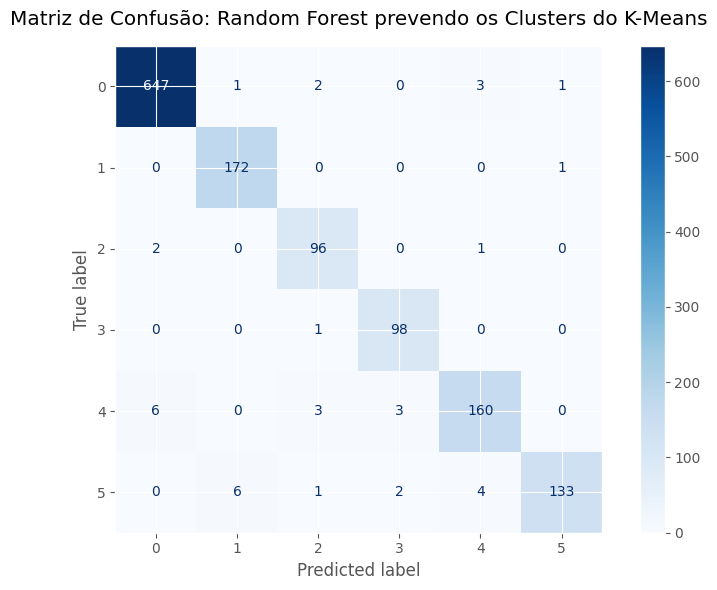

In [ ]:
# o RandomForest vai aprender as regras do K-Means usando os dados de Treino
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_scaled, labels_treino)

# rotulando os dados de Teste com KMeans
labels_teste_reais = kmeans_otimizado.predict(X_test_scaled)

# prevendo esses rótulos nos dados de Teste
labels_teste_previstos = rf_classifier.predict(X_test_scaled)

# avaliando a performance com a Matriz de Confusão
print(classification_report(labels_teste_reais, labels_teste_previstos))

# visualizando
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(labels_teste_reais, labels_teste_previstos, ax=ax, cmap='Blues')
plt.title('Matriz de Confusão: Random Forest prevendo os Clusters do K-Means', pad=15)
plt.tight_layout()
plt.show()

* **Performance do Random Forest (97% de Precisão)**: O modelo aprendeu os clusters e acertou 97%, isso prova que os grupos criados pelo K-Means não são aleatórios. Eles possuem regras claras e bem definidas baseadas nos dados (como limite, gastos e pagamentos).

* **A Matriz de Confusão**: Ela está quase toda na diagonal, o que é o cenário ideal. Isso significa que o modelo raramente confunde os tipos de cliente.

* **Distribuição dos Grupos**: Vemos que o Cluster 0 é a maior parte do público, enquanto grupos como o Cluster 2 e 3 são menores e mais específicos.

### Perfilamento dos Grupos (Cluster Profiling)
Analisando as médias originais (não escalonadas) de cada cluster para entender o comportamento real de cada segmento de cliente.

In [ ]:
# adicionando os labels ao dataframe de treino original para análise
df_perfil = X_train.copy()
df_perfil['Cluster'] = labels_treino

# calculando a média de cada característica por cluster
analise_clusters = df_perfil.groupby('Cluster').mean()

# exibindo o tamanho de cada grupo
print("Quantidade de clientes por cluster:")
display(df_perfil['Cluster'].value_counts().sort_index())

# visualizando as médias com gradiente de cores para identificar padrões
print("\nMédias por Cluster (Valores Reais):")
display(analise_clusters.style.background_gradient(cmap='YlGnBu', axis=0))

Quantidade de clientes por cluster:


,count
Cluster,
0,2961
1,774
2,511
3,463
4,873
5,683



Médias por Cluster (Valores Reais):


,BALANCE_FREQUENCY,PURCHASES,CASH_ADVANCE,ONEOFF_PURCHASES_FREQUENCY,CREDIT_LIMIT,PRC_FULL_PAYMENT,TENURE,CREDIT_UTILIZATION,PAYMENT_RATIO
Cluster,,,,,,,,,
0,0.983040,504.469780,632.378472,0.106247,3371.783181,0.027104,11.897332,0.547230,2.804239
1,0.381481,341.529470,374.521525,0.066958,3666.939420,0.086006,11.775194,0.048996,34.631329
2,0.961365,633.697397,6163.413765,0.118673,9423.296566,0.040807,11.720157,0.608358,6.159595
3,0.809605,418.698402,1168.478693,0.121675,2492.159827,0.139137,7.293737,0.383379,5.566499
4,0.984221,3829.120985,365.163083,0.787486,7744.558992,0.234469,11.943872,0.284565,9.566912
5,0.819109,971.361347,68.801267,0.140388,4270.760681,0.778575,11.773060,0.034241,9.280633


## Personas dos Segmentos Identificados

| Cluster | Nome Sugerido | Perfil de Comportamento |
| :--- | :--- | :--- |
| **0** | **Consumidor Equilibrado** | Um grupo de perfil misto, cujo comportamento é moldado pela combinação de manter saldo frequente, fazer pagamentos integrais e realizar compras à vista. |
| **1** | **Cliente do Rotativo** | Clientes definidos quase que inteiramente pela frequência com que deixam saldo rotativo acumulado no cartão. |
| **2** | **Sacador de Emergência** | O grupo focado em liquidez de emergência, caracterizado fortemente pelo uso do limite de crédito para saques em dinheiro. |
| **3** | **Cliente Veterano** | Clientes cujo diferencial e principal critério de agrupamento é o tempo de relacionamento e idade da conta. |
| **4** | **Comprador Ativo** | Consumidores altamente ativos, definidos pelo grande volume e alta frequência de compras em parcela única. |
| **5** | **Pagador Integral** | Os típicos "bons pagadores", isolados no grupo pela sua consistência inabalável em sempre pagar o valor total da fatura. |

## Explainable AI (SHAP)

### Por que cada cliente foi para seu grupo? (SHAP Global e por Cluster)
O gráfico abaixo mostra quais variáveis foram mais decisivas para o modelo conseguir separar os clientes nos 6 grupos identificados.

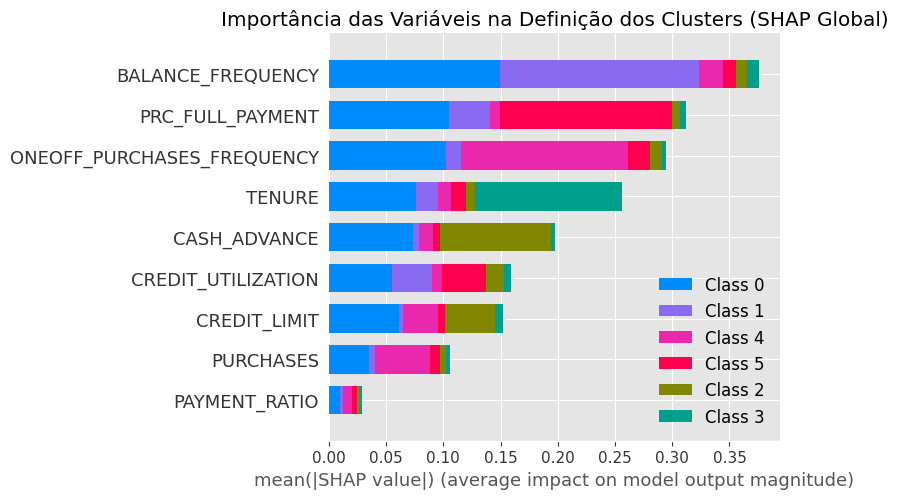

In [ ]:
# calculando valores SHAP usando o classificador treinado para explicar os clusters
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_test_scaled)

# visualizando a importância global das features para todos os clusters
plt.figure(figsize=(10, 6))
plt.title('Importância das Variáveis na Definição dos Clusters (SHAP Global)')
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=True)

### Fatores de Influência por Categoria (Personas)
Abaixo, vemos os principais drivers para cada um dos 6 grupos. Isso explica a lógica por trás de cada nome que demos.

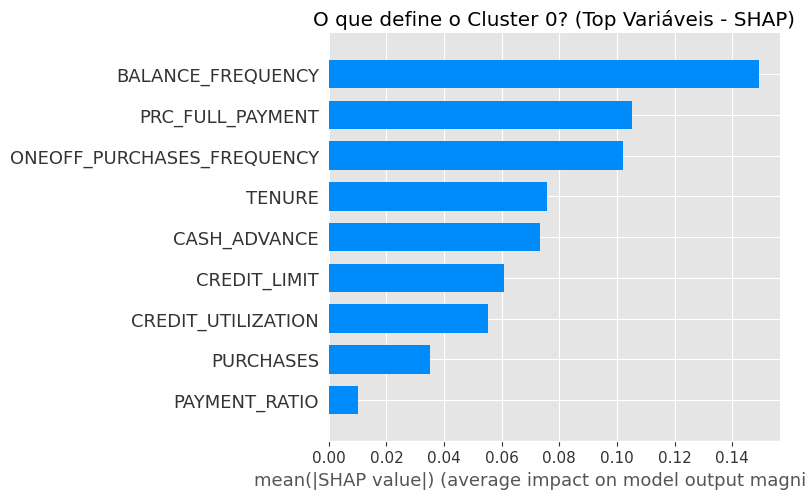

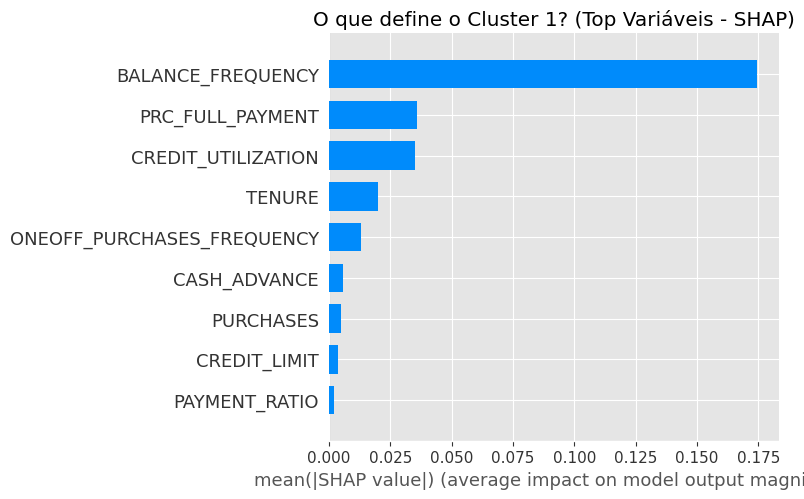

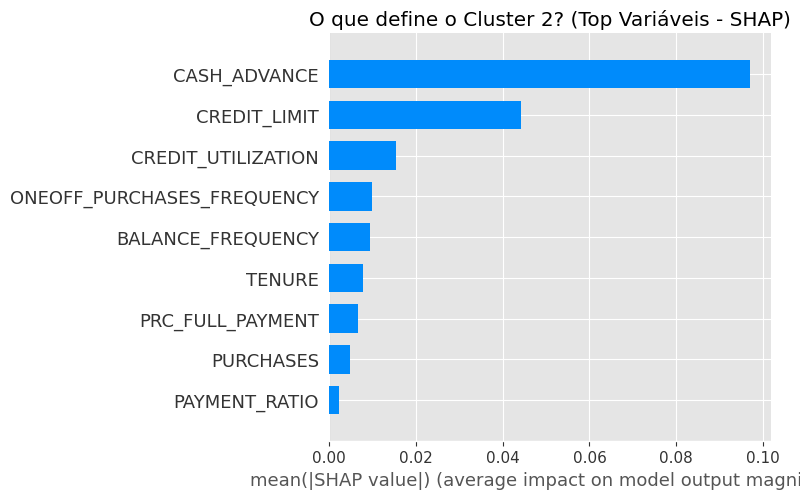

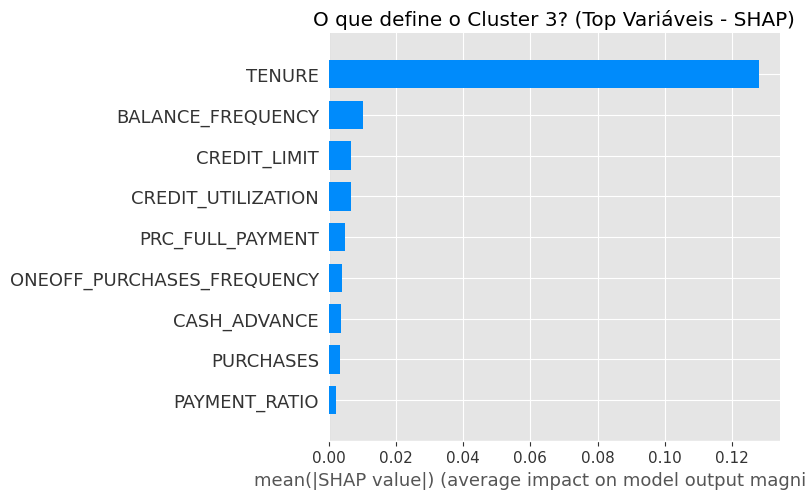

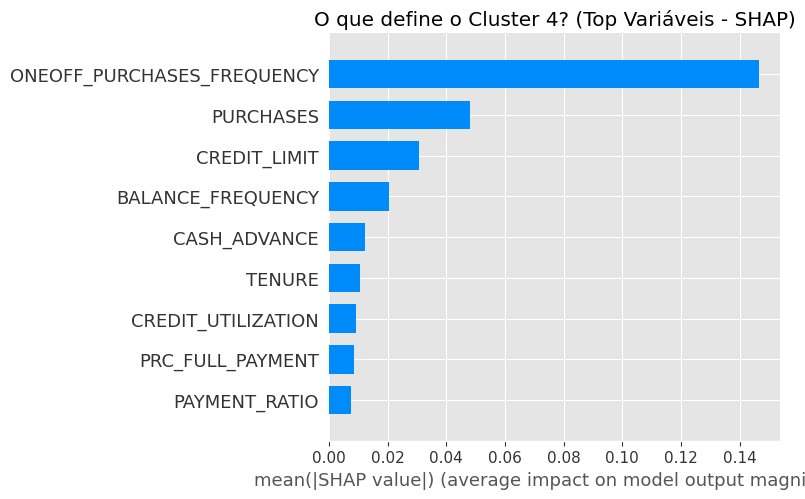

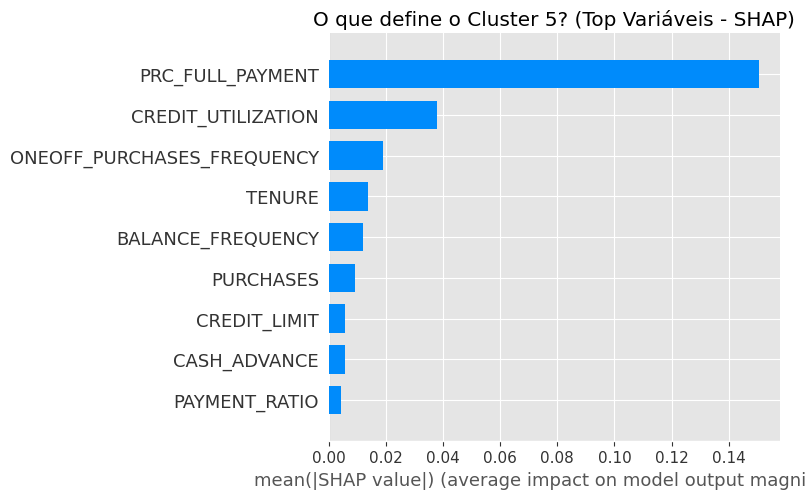

In [ ]:
# mostrando a importância das variáveis para cada cluster individualmente
for i in range(melhor_k):
    plt.figure(figsize=(8, 4))
    plt.title(f'O que define o Cluster {i}? (Top Variáveis - SHAP)')

    # acessando os valores da classe i
    current_shap_values = shap_values[i] if isinstance(shap_values, list) else shap_values[:, :, i]

    shap.summary_plot(current_shap_values, X_test_scaled, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()

## Personas dos Segmentos Identificados

| Cluster | Nome Sugerido | Perfil de Comportamento |
| :--- | :--- | :--- |
| **0** | **Consumidor Equilibrado** | Um grupo de perfil misto, cujo comportamento é moldado pela combinação de manter saldo frequente, fazer pagamentos integrais e realizar compras à vista. |
| **1** | **Cliente do Rotativo** | Clientes definidos quase que inteiramente pela frequência com que deixam saldo rotativo acumulado no cartão. |
| **2** | **Sacador de Emergência** | O grupo focado em liquidez de emergência, caracterizado fortemente pelo uso do limite de crédito para saques em dinheiro. |
| **3** | **Cliente Veterano** | Clientes cujo diferencial e principal critério de agrupamento é o tempo de relacionamento e idade da conta. |
| **4** | **Comprador Ativo** | Consumidores altamente ativos, definidos pelo grande volume e alta frequência de compras em parcela única. |
| **5** | **Pagador Integral** | Os típicos "bons pagadores", isolados no grupo pela sua consistência inabalável em sempre pagar o valor total da fatura. |

##A definição de cada cluster e as variáveis que os dominam:

### **Cluster 0 - Consumidor Equilibrado:**

Este cluster possui uma distribuição mais equilibrada de importância entre várias características, mas é liderado por três comportamentos de uso e pagamento:

* **BALANCE_FREQUENCY:** Frequência com que o saldo é mantido ou atualizado (indica se o cliente costuma deixar saldo no cartão frequentemente).
* **PRC_FULL_PAYMENT:** Percentual de meses em que o cliente pagou o valor total da fatura.
* **ONEOFF_PURCHASES_FREQUENCY:** Frequência com que o cliente realiza compras à vista (em parcela única).

### **Cluster 1 - Cliente do Rotativo:**

O Cluster 1 é **fortemente dominado** por uma única variável, que isola o comportamento deste grupo:

* **BALANCE_FREQUENCY:** Frequência de manutenção de saldo na conta. A diferença no impacto desta variável para as demais é massiva, indicando que este grupo é definido quase inteiramente pela constância (ou falta dela) em ter um saldo rotativo no cartão.

### **Cluster 2 - Sacador de Emergência:**

Este cluster representa um perfil muito específico de uso de crédito emergencial ou liquidez:

* **CASH_ADVANCE:** Valor de saques em dinheiro realizados com o cartão de crédito. É a característica absoluta que define este grupo.
* **CREDIT_LIMIT:** Limite de crédito do cliente (aparece em segundo lugar, sugerindo que o acesso ao limite dita o quanto podem sacar).

### **Cluster 3 - Cliente Veterano:**

O Cluster 3 é caracterizado majoritariamente pela lealdade ou idade da conta:

* **TENURE:** Tempo de relacionamento (em meses) do cliente com o serviço de cartão de crédito. Este é o fator decisivo para agrupar esses clientes, separando, por exemplo, clientes muito novos de clientes antigos.

### **Cluster 4 - Comprador Ativo:**

O Cluster 4 agrupa os consumidores ativos com foco em volume de transações e compras sem parcelamento:

* **ONEOFF_PURCHASES_FREQUENCY:** Frequência de compras à vista (pagamento único).
* **PURCHASES:** Volume (valor total) de compras realizadas.
* *(Estes clientes são definidos pelo alto engajamento em usar o cartão para compras do dia a dia ou grandes compras não parceladas).*

### **Cluster 5 - Pagador Integral:**

O Cluster 5 define o comportamento do "bom pagador" ou *transactor* (quem usa o cartão por conveniência e não para tomar crédito):

* **PRC_FULL_PAYMENT:** Percentual de pagamento integral da fatura. A dominância gigantesca desta variável indica que este cluster é formado por clientes definidos primariamente pelo hábito de não deixar saldo rotativo, pagando sempre (ou quase sempre) 100% do que devem.

## **Conclusão Final do Projeto**

Este projeto demonstrou a aplicação bem-sucedida de técnicas de **Aprendizado Não Supervisionado** para a segmentação estratégica de uma base de clientes de cartões de crédito. Através do algoritmo **K-Means** (otimizado via Optuna) e da validação via **Explainable AI (SHAP)**, conseguimos transformar dados brutos em 6 perfis comportamentais distintos e acionáveis.

### **Principais Resultados:**
*   **Consistência dos Segmentos:** A precisão de **97%** obtida pelo classificador Random Forest confirmou que os grupos identificados não são aleatórios, mas possuem padrões matemáticos robustos.
*   **Identificação de Oportunidades:** Segmentamos desde o 'Pagador Integral' (baixo risco, alta conveniência) até o 'Cliente do Rotativo' e 'Sacador de Emergência', permitindo que a operadora ajuste suas taxas e ofertas de forma personalizada.
*   **Mitigação de Risco:** O mapeamento do grupo de risco (alta utilização de limite e baixo pagamento) oferece uma ferramenta preventiva contra a inadimplência.

### **Próximos Passos Sugeridos:**
*   Implementar testes A/B para campanhas de marketing direcionadas a cada cluster.
*   Monitorar a migração de clientes entre clusters ao longo do tempo (Análise de Churn e LTV).
*   Integrar este modelo em um pipeline de produção para rotulagem automática de novos clientes.

Com esta análise, a empresa deixa de tratar sua base como uma massa uniforme e passa a ter uma visão granular, orientada a dados, para cada tipo de consumidor.

### Exportação do Modelo
Salvando o modelo treinado e o escalonador para uso futuro em produção.

In [ ]:
# salvando o modelo de Clustering
joblib.dump(kmeans_otimizado, 'kmeans_model.joblib')

# salvando o scaler
joblib.dump(scaler, 'standard_scaler.joblib')

# salvando o classificador Random Forest (validação)
joblib.dump(rf_classifier, 'random_forest_model.joblib')

['random_forest_model.joblib']

### Exemplo de Caso de Uso (Produção)
Simulação de como utilizar os arquivos exportados para classificar um novo cliente que entra na base.

In [ ]:

# carregar os artefatos salvos
scaler_prod = joblib.load('standard_scaler.joblib')
kmeans_prod = joblib.load('kmeans_model.joblib')
rf_prod = joblib.load('random_forest_model.joblib')

# simular a entrada de um novo cliente
# Vamos pegar um cliente aleatório para teste
novo_cliente_raw = X_test.iloc[[10]]

# pré-processamento (Escalonamento)
novo_cliente_scaled = scaler_prod.transform(novo_cliente_raw)

# predição
cluster_atribuido = kmeans_prod.predict(novo_cliente_scaled)[0]
probabilidades = rf_prod.predict_proba(novo_cliente_scaled)[0]

# dicionário de Personas (mapeamento feito no estudo)
personas = {
    0: "Consumidor Equilibrado",
    1: "Cliente do Rotativo",
    2: "Sacador de Emergência",
    3: "Cliente Veterano",
    4: "Comprador Ativo",
    5: "Pagador Integral"
}

print(f"Cluster Identificado: {cluster_atribuido}")
print(f"Persona: {personas[cluster_atribuido]}")
print(f"Confiança da Classificação (RF): {max(probabilidades)*100:.2f}%")

print("\nDados do Cliente:")
display(novo_cliente_raw)

Cluster Identificado: 1
Persona: Cliente do Rotativo
Confiança da Classificação (RF): 100.00%

Dados do Cliente:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,BALANCE_FREQUENCY,PURCHASES,CASH_ADVANCE,ONEOFF_PURCHASES_FREQUENCY,CREDIT_LIMIT,PRC_FULL_PAYMENT,TENURE,CREDIT_UTILIZATION,PAYMENT_RATIO
7061,0.454545,0.0,189.391686,0.0,1500.0,0.0,12,0.047892,0.338928
